In [ ]:

import os
import numpy as np
import flopy
import matplotlib.pyplot as plt

# Define the bed elevation for filtering particles
bed_elevation = 1599.8125  # Replace with the actual bed elevation value
ncol = 215
nrow = 192
#\Users\u4eeevmq\Documents\Python\HP_workspace
# Define the workspace and file names
workspace = r"C:\Users\u4eeevmq\Documents\Python\HP_workspace\mp7_workspace"
workspace_gwf = r"C:\Users\u4eeevmq\Documents\Python\HP_workspace\gwf_workspace"

model_name = "Hyporheic_Project_mp"  # Replace with your model name

#     r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\mp7_workspace\Hyporheic_Project_mp_backward.mppth"

# Define the MODPATH 7 pathline and endpoint files
f_pathline_file = os.path.join(workspace_gwf, model_name + "_forward.mppth")
endpoint_file = os.path.join(workspace_gwf, model_name + "_forward.mpend")


Converted Particle IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217,

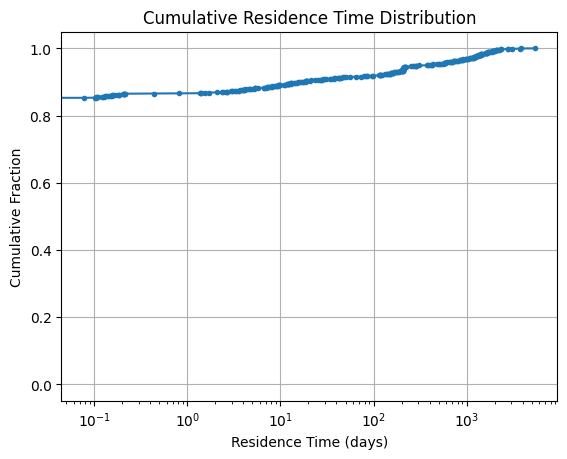

In [57]:
# Read endpoint data
endpoint_reader = flopy.utils.EndpointFile(endpoint_file)
endpoints = endpoint_reader.get_alldata()

# Filter particles that end at or above the bed elevation
filtered_particles = [ep for ep in endpoints if ep['z'] >= bed_elevation]
filtered_particle_ids = [ep['particleid'] for ep in filtered_particles]

# Convert particle IDs to plain Python integers
filtered_particle_ids = [int(ep['particleid']) for ep in filtered_particles]

print(f"Converted Particle IDs: {filtered_particle_ids}")
print(f"Total particles ending at or above bed elevation: {len(filtered_particles)}")
print(f"Particle IDs ending at or above bed elevation: {filtered_particle_ids}")
print("Available fields in endpoint data:", endpoints[0].dtype.names)

# Convert filtered_particle_ids into a list
particle_ids_list = list(filtered_particle_ids)

# Print the resulting list
print(particle_ids_list)

# Extract residence times (total travel time) for filtered particles
residence_times = [ep['time'] for ep in filtered_particles]

# Print a few to check
print("Example residence times:", residence_times[:5])

# Sort residence times
residence_times_sorted = np.sort(residence_times)

# Calculate cumulative fraction
cumulative_fraction = np.linspace(0, 1, len(residence_times_sorted))

# Plot
plt.figure()
plt.plot(residence_times_sorted, cumulative_fraction, marker='.', linestyle='-')
plt.xscale('log')  # log scale on x-axis, like your figure
plt.xlabel('Residence Time (days)')
plt.ylabel('Cumulative Fraction')
plt.title('Cumulative Residence Time Distribution')
plt.grid(True)
plt.show()


Maximum residence time (minutes): 7754829.00
Log Bins: [1.1142680e+02 3.8463995e+02 1.3277585e+03 4.5833584e+03 1.5821524e+04
 5.4615168e+04 1.8852903e+05 6.5079275e+05 2.2465040e+06 7.7548275e+06]


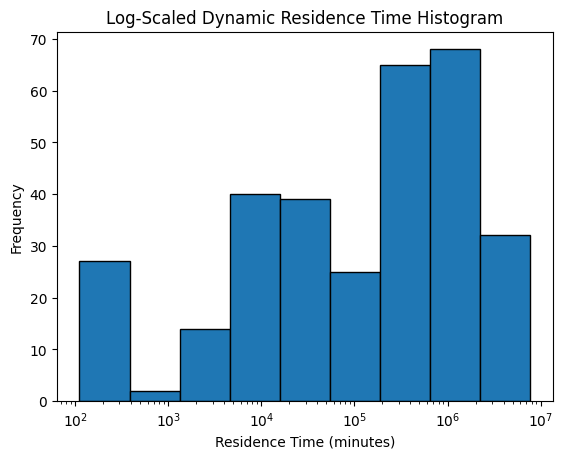

In [58]:
# Convert to minutes if needed (if your model uses days, multiply by 1440)
residence_times_min = np.array(residence_times) * 1440
max_time = np.max(residence_times_min)
print(f"Maximum residence time (minutes): {max_time:.2f}")

# Plotting the histogram of residence times in Log-Bins
min_time = np.min(residence_times_min[residence_times_min > 0])  # avoid zero for log
num_bins = 10

bins = np.logspace(np.log10(min_time), np.log10(max_time), num_bins)

print("Log Bins:", bins)

# Now plot
plt.figure()
plt.hist(residence_times_min, bins=bins, edgecolor='black')
plt.xscale('log')
plt.xlabel('Residence Time (minutes)')
plt.ylabel('Frequency')
plt.title('Log-Scaled Dynamic Residence Time Histogram')
#plt.grid(True, which="both", ls="--")
plt.show()


In [ ]:
# Read pathline data only for selected partticles
pathline_reader = flopy.utils.PathlineFile(f_pathline_file)

# Load pathline data for all particle IDs in the list
filtered_pathlines = []
for particle_id in particle_ids_list:
    filtered_pathlines.extend(pathline_reader.get_data(partid=particle_id))

# Print the total number of pathlines and the particle IDs list
print(f"Total pathlines corresponding to filtered particles: {len(filtered_pathlines)}")
print("Particle IDs List:", particle_ids_list)

print(type(filtered_pathlines))


Total pathlines corresponding to filtered particles: 35314
Particle IDs List: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 

In [60]:
# Plot MODPATH 7 output
import pandas as pd
print("Available fields in pathline data:", filtered_pathlines[0].dtype.names)

# Available fields in pathline data
column_names = [
    'particleid', 'particlegroup', 'sequencenumber', 'particleidloc', 'time',
    'x', 'y', 'z', 'k', 'node', 'xloc', 'yloc', 'zloc', 'stressperiod', 'timestep'
]

# Convert NumPy structured array to DataFrame and add column names
if isinstance(filtered_pathlines, list) and hasattr(filtered_pathlines[0], 'dtype'):
    filtered_pathlines_df = pd.DataFrame.from_records(filtered_pathlines, columns=column_names)

# Print the first few rows to check the structure
print(filtered_pathlines_df.head())

required_fields = ['x', 'y', 'z', 'time', 'k', 'particleid']
missing_fields = [field for field in required_fields if field not in filtered_pathlines_df.columns]
print("Missing fields:", missing_fields)



Available fields in pathline data: ('particleid', 'particlegroup', 'sequencenumber', 'particleidloc', 'time', 'x', 'y', 'z', 'k', 'node', 'xloc', 'yloc', 'zloc', 'stressperiod', 'timestep')
   particleid  particlegroup  sequencenumber  particleidloc  time       x  \
0           0              0               0              0   0.0  1175.0   
1           0              0               0              0   0.0  1175.0   
2           1              0               1              1   0.0  1185.0   
3           1              0               1              1   0.0  1185.0   
4           2              0               2              2   0.0  1135.0   

        y           z  k   node  xloc  yloc  zloc  stressperiod  timestep  
0  1315.0  1605.56250  0  13017   0.5   0.5   0.5             1         1  
1  1315.0  1605.56250  0  13017   0.5   0.5   0.5             1         1  
2  1315.0  1606.06250  0  13018   0.5   0.5   0.5             1         1  
3  1315.0  1606.06250  0  13018   0.5   0.5

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package chd...
    loading package oc...
  loading solution package gwf_model...
['gwf_model']
Spatial Extent: [2406093.51, np.float64(2408243.51), 10514475.4, np.float64(10516395.4)]


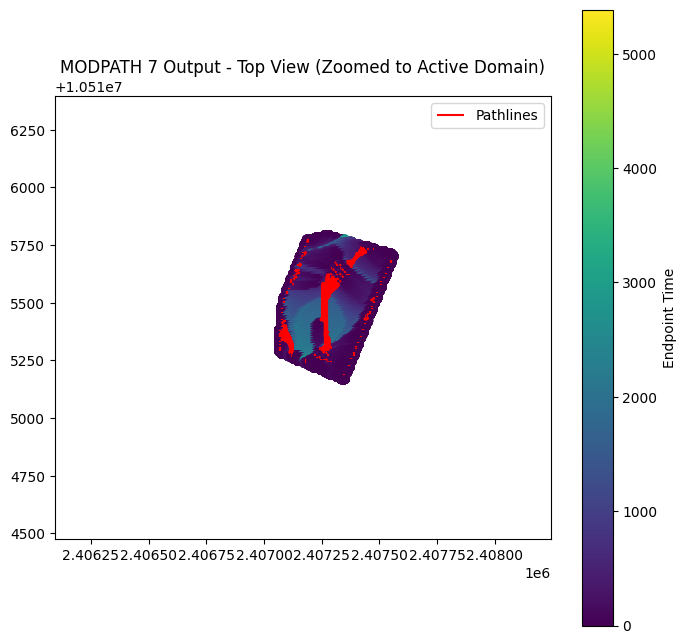

In [61]:
# Correct the simulation workspace path
model_ws = r"C:\Users\u4eeevmq\Documents\Python\HyporheicFloPy\HP_workspace\gwf_workspace"

# Load the MODFLOW 6 simulation
sim = flopy.mf6.MFSimulation.load(sim_ws=model_ws)
print(sim.model_names)

# Access the groundwater flow (GWF) model
gwf = sim.get_model("gwf_model")  # Replace "gwf_model" with your model name if different

# Get DIS package and idomain array
dis = gwf.get_package("DIS")

# Get model grid information
xorigin = dis.xorigin
yorigin = dis.yorigin
delr = dis.delr.array  # Column widths
delc = dis.delc.array  # Row heights

# Calculate spatial extents
x_min = xorigin.data  # Access the numerical value from MFScalar
x_max = xorigin.data + delr.sum()  # Access data and perform addition
y_min = yorigin.data  # Access the numerical value from MFScalar
y_max = yorigin.data + delc.sum()  # Access data and perform addition

extent = [x_min, x_max, y_min, y_max]
print(f"Spatial Extent: {extent}")

# Plot top view
plt.figure(figsize=(8, 8))
mm = flopy.plot.PlotMapView(model=gwf)

# Plot grid (optional, set lw=0 to hide grid lines)
mm.plot_grid(lw=0)

# Plot pathlines
mm.plot_pathline(filtered_pathlines_df, layer="all", colors="red", label="Pathlines")

# Plot endpoints (if available)
mm.plot_endpoint(endpoints, direction="starting", colorbar=True)

# Apply spatial extent for zooming
mm.ax.set_xlim(extent[0], extent[1])
mm.ax.set_ylim(extent[2], extent[3])

# Add title and legend
plt.title("MODPATH 7 Output - Top View (Zoomed to Active Domain)")
mm.ax.legend()
plt.show()

   particleid  particlegroup  sequencenumber  particleidloc  time       x  \
0           0              0               0              0   0.0  1175.0   
1           0              0               0              0   0.0  1175.0   
2           1              0               1              1   0.0  1185.0   
3           1              0               1              1   0.0  1185.0   
4           2              0               2              2   0.0  1135.0   

        y           z  k   node  xloc  yloc  zloc  stressperiod  timestep  
0  1315.0  1605.56250  0  13017   0.5   0.5   0.5             1         1  
1  1315.0  1605.56250  0  13017   0.5   0.5   0.5             1         1  
2  1315.0  1606.06250  0  13018   0.5   0.5   0.5             1         1  
3  1315.0  1606.06250  0  13018   0.5   0.5   0.5             1         1  
4  1305.0  1604.09375  0  13228   0.5   0.5   0.5             1         1  


C:\Users\u4eeevmq\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


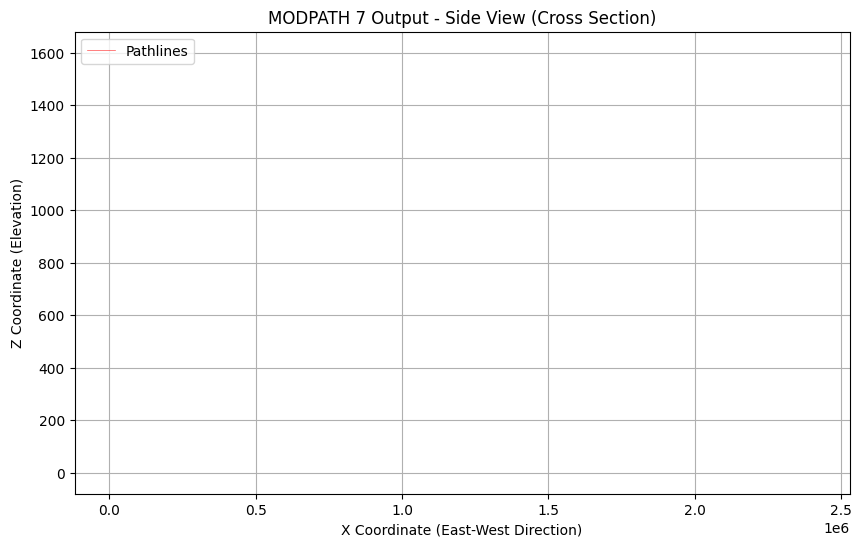

In [75]:
# Access DIS package to get model grid information
botm = dis.botm.array  # Bottom elevations of layers
nlay, nrow, ncol = botm.shape  # Number of layers, rows, and columns

print(filtered_pathlines_df[:5])  # Display the first 5 elements

# Create x-coordinates for the grid
x_coords = xorigin.data + np.cumsum(delr) - (delr / 2)  # Center of each column in the x-direction

# Plot side view
plt.figure(figsize=(10, 6))

# Plot grid layers (botm)
for layer in range(nlay):
    plt.plot(
        x_coords, botm[layer, 0, :],
        color="black", lw=0.5,
    )

# Plot pathlines in the side view using column indices
for i, pathline in filtered_pathlines_df.iterrows():  # Assuming it's a Pandas DataFrame
    plt.plot(
        pathline.iloc[5],  # x-coordinate (column index 5)
        pathline.iloc[8],  # z-coordinate (column index 8)
        color="red", lw=0.5, alpha=0.7,
        label="Pathlines" if i == 0 else ""  # Add label only for the first pathline
    )


# Add labels and legend
plt.xlabel("X Coordinate (East-West Direction)")
plt.ylabel("Z Coordinate (Elevation)")
plt.title("MODPATH 7 Output - Side View (Cross Section)")
plt.legend()
plt.grid(True)

plt.show()

Residence Times: Min = 0.0, Max = 5385.2978515625


C:\Users\u4eeevmq\AppData\Local\Temp\ipykernel_28796\73390575.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  mm.ax.legend()


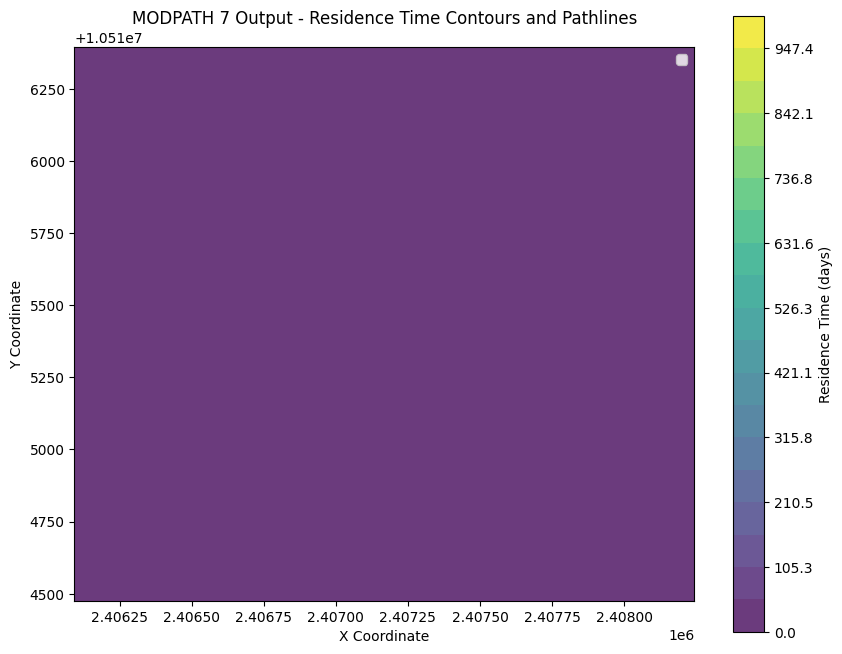

In [ ]:
from scipy.interpolate import griddata

# Interpolate residence time onto a grid
# Extract residence times (total travel time) for filtered particles
residence_times = [ep['time'] for ep in filtered_particles]

# Extract x and y positions for filtered particles
x_positions = [ep['x'] for ep in filtered_particles]
y_positions = [ep['y'] for ep in filtered_particles]

# Ensure residence times are valid
print(f"Residence Times: Min = {np.min(residence_times)}, Max = {np.max(residence_times)}")
residence_times = [t for t in residence_times if t > 0]  # Filter out negative or zero times

# Combine x, y, and residence_times into a single list of tuples
filtered_data = [(x, y, t) for x, y, t in zip(x_positions, y_positions, residence_times) if t > 0]

# Unpack the filtered data back into separate lists
x_positions, y_positions, residence_times = zip(*filtered_data)

# Convert back to lists if needed
x_positions = list(x_positions)
y_positions = list(y_positions)
residence_times = list(residence_times)

# Clip residence times for better visualization
max_residence_time = 1000  # Define a max value for plotting
residence_times = np.clip(residence_times, 0, max_residence_time)

# Create a meshgrid for interpolation
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 2119),  # 100 points along x-axis
    np.linspace(y_min, y_max, 2119),  # 100 points along y-axis
)

# Interpolate residence times onto the grid
grid_residence_time = griddata(
    (x_positions, y_positions),
    residence_times,
    (grid_x, grid_y),
    method='linear',
    fill_value=0  # Fallback value for missing data
)

# Plot combined visualization
plt.figure(figsize=(10, 8))
mm = flopy.plot.PlotMapView(model=gwf)

# Plot residence time contours
contour_levels = np.linspace(0, max_residence_time, 20)  # 20 levels between 0 and max residence time
contour = plt.contourf(grid_x, grid_y, grid_residence_time, levels=contour_levels, cmap="viridis", alpha=0.8)
cbar = plt.colorbar(contour)
cbar.set_label("Residence Time (days)")

# Plot pathlines
mm.plot_pathline(filtered_pathlines_df, layer="all", colors="blue", label="Pathlines")

# Apply spatial extent for zooming
mm.ax.set_xlim(extent[0], extent[1])
mm.ax.set_ylim(extent[2], extent[3])

# Add title and legend
plt.title("MODPATH 7 Output - Residence Time Contours and Pathlines")
mm.ax.legend()
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.show()